# Loading Track Data 

## Introduction

Tracklib loads GNSS data from one or more CSV or GPX files. Geometries can be provided either as coordinate pairs or in WKT format.

Timestamps, when available, can be given as text or Unix time. `AnalyticalFeature`s (AF) can optionally be loaded, and the input data can be filtered during import.


### Reading Methods

All data import methods are provided by the `TrackReader` class.

Depending on the input format, you can use one of the dedicated static methods:

> * `TrackReader.readFromGpx(...)` -> TrackCollection
> * `TrackReader.readFromCsv(...)` -> Track or TrackCollection
> * `TrackReader.readFromWkt(...)` -> TrackCollection

### Time Field

The format of the time field must be specified using the static method `ObsTime.setReadFormat()` before loading the data. The format string defines the timestamp template used to parse observation timestamps.

For example:

```python
  ObsTime.setReadFormat("4Y-2M-2DT2h:2m:2sZ")
```
or
```python
  ObsTime.setReadFormat("2D/2M/4Y 2h:2m:2s")
```

### Coordinate Reference System (CRS)

Regardless of how the import options are specified, the coordinate type is defined using the srid parameter.


**Geographic coordinates**

```python
    srid="GeoCoords"
    # or
    srid = "GEO" 
```
    
**Local coordinates**
```python
    srid="ENUCoords"
    # or
    srid="ENU"
```



### Importing Tracklib

The following examples require importing the Tracklib library first.

In [1]:
import matplotlib.pyplot as plt

import os
import sys

# Import the Tracklib library
import tracklib as tkl

Code running in a no shapely environment


## Loading GPX Files

Whether you specify the path to a single GPX file or to a directory containing multiple GPX files, `TrackReader.readFromGpx(...)` always returns a `TrackCollection`.

When the collection contains only one track, you can access it using standard indexing:

```python
collection = tkl.TrackReader.readFromGpx(...)
track = collection[0]
```

### Loading a Single GPX File

In this case, the first argument is the path to a GPX file.

The `type` parameter (`"trk"` or `"rte"`) specifies whether tracks or routes should be imported from the file.

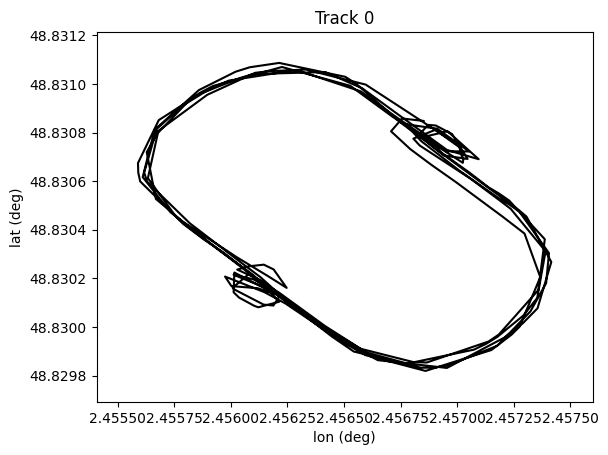

In [2]:
tkl.ObsTime.setReadFormat("4Y-2M-2DT2h:2m:2sZ")

resource_path = '../../../data/gpx/'
filepath = os.path.join(resource_path, 'activity_5807084803.gpx')

tracks = tkl.TrackReader.readFromGpx(filepath, srid='GEO', type='trk')

tracks[0].plot()

### Loading a Directory of GPX Files

In this case, the first argument is the path to a directory.

`TrackReader.readFromGpx()` creates one track in the returned `TrackCollection` for each GPX file found in the directory.

2  GPX tracks loaded


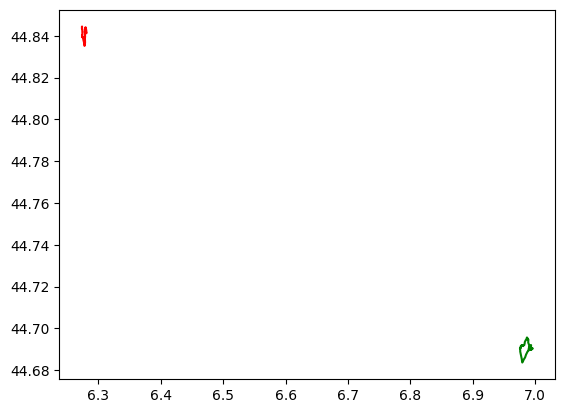

In [3]:
resource_path = '../../../data/gpx/geo'
tkl.ObsTime.setReadFormat("4Y-2M-2DT2h:2m:2sZ")

collection = tkl.TrackReader.readFromGpx(resource_path)

print (collection.size(), ' GPX tracks loaded')
collection.plot()

## Loading CSV files

Unlike GPX files, a single CSV file is loaded as a `Track`, whereas a directory containing multiple CSV files is loaded as a `TrackCollection`.

### Main Parameters :

- `id_E`: index (starting from 0) of the column containing the X coordinate (ECEF), longitude (GEO), or East coordinate (ENU).
- `id_N`: index (starting from 0) of the column containing the Y coordinate (ECEF), latitude (GEO), or North coordinate (ENU).
- `id_U`: index (starting from 0) of the column containing the Z coordinate (ECEF), height, or altitude.
- `id_T`: index (starting from 0) of the column containing the timestamp
- `separator`: field separator. The predefined values are `c` (comma), `b` (blank space), and `s` (semicolon). Custom separators are also supported.
- `header`: number of header lines to skip.


### Loading a Single CSV File

In this case, the first argument is the path to a CSV file, and the method returns a `Track`.

The simplest way to load a CSV file is to specify the column indices for the coordinates and timestamp.

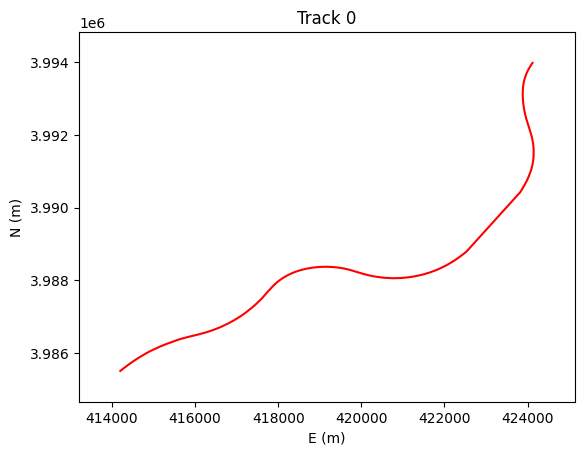

In [4]:
tkl.ObsTime.setReadFormat("4Y-2M-2D 2h:2m:2s")

resource_path = '../../../data'
filepath = os.path.join(resource_path, 'trace10_mm.dat')

track = tkl.TrackReader.readFromCsv(filepath, id_E=2, id_N=3, id_T=1, id_U=-1, h=1, separator=',', srid='ENU')

track.plot('r-')

### Loading Multiple CSV Files

In this case, the first argument is the path to a directory, and the method returns a `TrackCollection` containing one track for each CSV file.


2  CSV tracks loaded



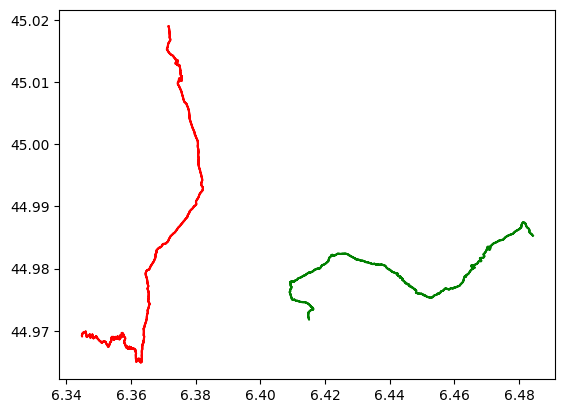

In [5]:
tkl.ObsTime.setReadFormat("2D/2M/4Y 2h:2m:2s")
resource_path = '../../../data/test/csv'

collection = tkl.TrackReader.readFromCsv(resource_path, 1, 2, -1, -1)

print ('')
print (collection.size(), ' CSV tracks loaded')
print('')

collection.plot()

### Reading Timestamps in Milliseconds

As an example, consider the following Unix timestamp:

- `1412412627743` represents the number of **milliseconds elapsed since the Unix epoch**.
- The Unix epoch is **1970-01-01 00:00:00 UTC**.
- This timestamp corresponds to **Saturday, October 4, 2014, 08:50:27.743 UTC**.

To read timestamps stored in this format:

- `id_T`: index of the column containing the timestamp (`id_T = 2`).
- `DateIni`: reference date from which timestamps are measured, specified as an `ObsTime` object.

```python
initialDate = "1970-01-01 00:00:00"
time_ini = ObsTime.readTimestamp(initialDate)
```

- `timeUnit`: timestamp unit (`1` for seconds or `0.001` for milliseconds).



Human-readable date for the first observation:   04/10/2014 08:50:27
Human-readable date for the 10th observation:    04/10/2014 08:50:46
Human-readable date for the 20th observation:    04/10/2014 08:51:06
etc.


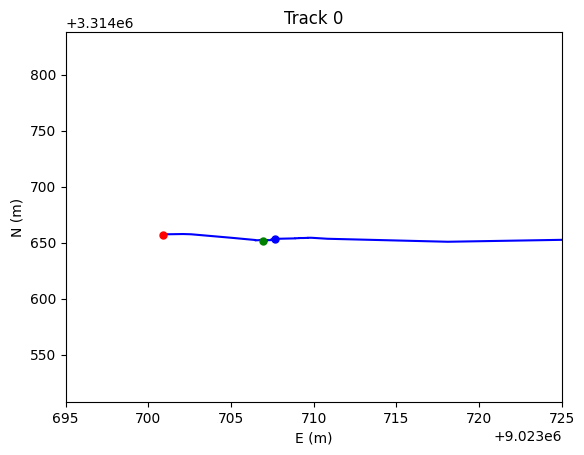

In [6]:
resource_path = '../../../data/mopsi/'
filepath = os.path.join(resource_path, '1412412627743_3857.csv')

tkl.ObsTime.setReadFormat("4Y-2M-2D 2h:2m:2s")

initialDate = '1970-01-01 00:00:00'
track = tkl.TrackReader.readFromCsv(path=filepath, id_E=1, id_N=0, id_U=3, h=0, separator=',', srid="ENU",
                                      id_T=2, timeUnit=0.001,
                                      DateIni = tkl.ObsTime.readTimestamp(initialDate))

print ('')
print ("Human-readable date for the first observation:  ", track[0].timestamp)
print ("Human-readable date for the 10th observation:   ", track[9].timestamp)
print ("Human-readable date for the 20th observation:   ", track[19].timestamp)
print ('etc.')

track.plot('b-')
plt.xlim([9023695, 9023725])
plt.ylim([3314508, 3314838])
plt.plot(track[0].position.getX(), track[0].position.getY(), 'ro', markersize=5)
plt.plot(track[9].position.getX(), track[9].position.getY(), 'go', markersize=5)
plt.plot(track[19].position.getX(), track[19].position.getY(), 'bo', markersize=5)

### Selecting Tracks During Import

Tracks can be selected while they are being loaded by providing a selector.

For example, the following example selects only the tracks whose observations fall within a given rectangular bounding box. More complex selection rules are described in the **Selection** guide.

-------------------------------------
Number of GPS track: 23
-------------------------------------
  Nb of pt(s):   [42, 13, 40, 68, 65, 98, 58, 95, 15, 46, 803, 43, 100, 546, 73, 532, 76, 75, 868, 364, 17, 42, 36]



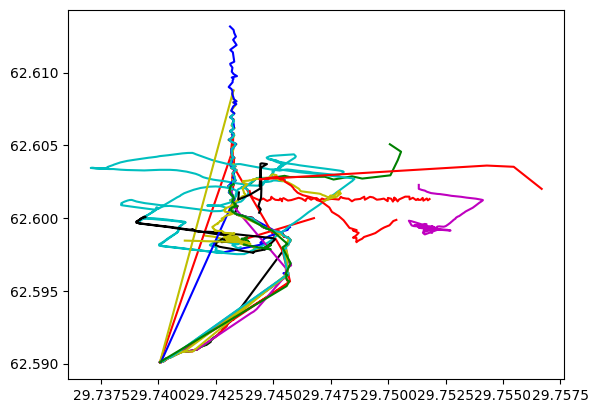

In [7]:
Xmin = 29.72
Xmax = 29.77
Ymin = 62.585
Ymax = 62.615

ll = tkl.ENUCoords(Xmin, Ymin)
ur = tkl.ENUCoords(Xmax, Ymax)
bbox = tkl.Rectangle(ll, ur)

# TYPE_CUT_AND_SELECT
constraintBBox = tkl.Constraint(shape = bbox, mode = tkl.MODE_INSIDE, 
                                type=tkl.TYPE_SELECT)
s = tkl.Selector([constraintBBox])

PATH = '/home/md_vandamme/5_DATA/GPX/MOPSI/0/'
tkl.ObsTime.setReadFormat("4Y-2M-2D 2h:2m:2s")
dateInitiale = '1970-01-01 00:00:00'

collection = tkl.TrackReader.readFromCsv(path=PATH, 
                                         id_E=1, id_N=0, srid="ENUCoords",
                                         id_T=2, timeUnit=0.001, DateIni = tkl.ObsTime.readTimestamp(dateInitiale),
                                         selector = s, 
                                         separator = ' ', h=0,
                                         verbose=False)

collection.summary()
collection.plot()

### Loading Analytical Features

If the CSV file contains analytical features stored in additional columns, they can all be imported by setting `read_all=True`.

When enabled, every column that is not used for coordinates or timestamps is loaded as an `AnalyticalFeature`.

In [8]:
tkl.ObsTime.setReadFormat("2D/2M/4Y 2h:2m:2s")

resource_path = '../../../data/test'
chemin = os.path.join(resource_path, 'ecrins_interpol4.csv')

track = tkl.TrackReader.readFromCsv(chemin, 0, 1, 2, 3, separator=";",read_all=True)

print (track.getListAnalyticalFeatures())

for i in range(119, 123):
    AF_Obs = track.getObsAnalyticalFeatures(['angledeg', 'sommet', 'virage'], i)
    print ('    AF for Observation', i, ':', AF_Obs)


['anglegeom', 'angledeg', 'sommet', 'sommet2', 'virage', 'serie']
    AF for Observation 119 : [10313.544485118573, 0.0, 1.0]
    AF for Observation 120 : [10313.544485118573, 0.0, 1.0]
    AF for Observation 121 : [9412.451270812637, 0.0, 1.0]
    AF for Observation 122 : [4422.152240830277, 0.0, 1.0]


## Loading CSV Files with WKT Geometry

If the geometry is stored as WKT, Tracklib can read it directly from the corresponding column.

For example, a track can be stored as a `LINESTRING`.

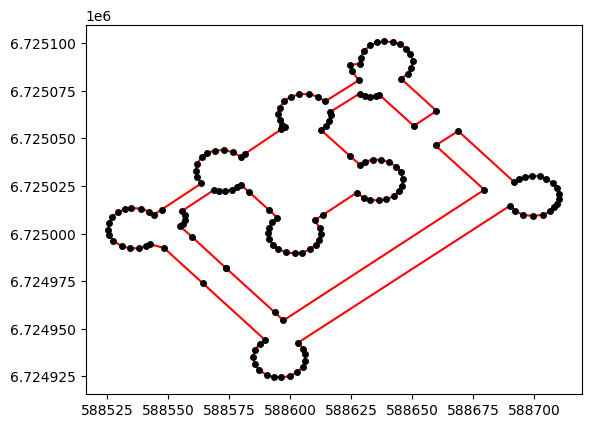

In [9]:
resource_path = '../../../data/wkt'
csvpath = os.path.join(resource_path, 'chambord.wkt')

TRACES = tkl.TrackReader.readFromWkt(csvpath, id_geom=0, 
                                     separator="#", h=1, 
                                     doublequote=True)
TRACES.plot()
TRACES.plot('ko')